# 03 - Training MLP with PyTorch

## Objetivo
Construir e treinar um MLP (Multi-Layer Perceptron) em PyTorch com:
- Arquitetura de 4 camadas ocultas com BatchNormalization
- Loop de treinamento com early stopping baseado em ROC-AUC
- Batching eficiente e validação estratificada
- MLflow tracking de experimentos
- Comparação com baseline LogisticRegression (ROC-AUC ~0.84)

In [13]:
# Fase 1.1 - Imports e Configuração Inicial

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    recall_score, f1_score, confusion_matrix, roc_curve, auc
)

# MLflow
import mlflow
import mlflow.pytorch

# Project utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from tracking.mlflow_utils import (
    build_default_run_tags,
    configure_mlflow_tracking,
    get_owner,
    normalize_params,
 )

# Configurações
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Configurar MLflow
repo_root = Path("..").resolve()
tracking_db = repo_root / "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{tracking_db.as_posix()}")
mlflow.set_experiment("tech_challenge_churn_local")
DATA_PATH = Path("../data/processed")
print(f"✓ Setup concluído. Device: {device}")

Device: cpu
✓ Setup concluído. Device: cpu


In [14]:
# Fase 1.2 - Carregar Dados Processados

# Carregar dataset codificado e pré-processado
df = pd.read_csv(DATA_PATH / "telco_customer_churn_eda_pre-processed_encoded.csv")

print(f"Dataset shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")

# Separar features e target
# Assumir que a última coluna é o target 'target' ou 'churn'
# target_col = 'target' if 'target' in df.columns else [col for col in df.columns if 'churn' in col.lower()][0]
# X = df.drop(columns=[target_col])
# y = df[target_col].values
X = df.drop(columns=['target'])
y = df['target'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target value counts:\n{pd.Series(y).value_counts()}")
print(f"Class distribution: {pd.Series(y).value_counts(normalize=True)}")

# Converter para float32 para PyTorch
X = X.astype(np.float32)
y = y.astype(np.float32)

print(f"\n✓ Dados carregados e preparados")

Dataset shape: (7043, 38)
Colunas: ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'target', 'CLTV', 'avg_ticket', 'Total Charges Log', 'avg_ticket_log', 'is_new_customer', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']

Features shape: (7043, 37)
Target shape: (7043,)
Target

In [15]:
# Fase 1.3 - Estratificação: Train → (Train + Validation) + Test

# Primeiro split: separar test set (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Segundo split: separar validation de training (20% do trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

print("Split estratificado concluído:")
print(f"  Train: {X_train.shape} - Churn: {y_train.sum():.0f} ({y_train.mean()*100:.1f}%)")
print(f"  Validation: {X_val.shape} - Churn: {y_val.sum():.0f} ({y_val.mean()*100:.1f}%)")
print(f"  Test: {X_test.shape} - Churn: {y_test.sum():.0f} ({y_test.mean()*100:.1f}%)")

# Salvar para referência
n_features = X_train.shape[1]
n_pos = (y_train == 1).sum()  # Churners
n_neg = (y_train == 0).sum()  # Non-churners
pos_weight = n_neg / n_pos  # Para weighted loss. Serve para equilibrar a perda entre classes desbalanceadas e fazer o modelo prestar mais atenção aos churners.

print(f"\nn_features: {n_features}")
print(f"n_pos (churners): {n_pos}")
print(f"n_neg (non-churners): {n_neg}")
print(f"pos_weight para BCELoss: {pos_weight:.2f}")

print(f"\n✓ Split estratificado concluído")

Split estratificado concluído:
  Train: (4507, 37) - Churn: 1196 (26.5%)
  Validation: (1127, 37) - Churn: 299 (26.5%)
  Test: (1409, 37) - Churn: 374 (26.5%)

n_features: 37
n_pos (churners): 1196
n_neg (non-churners): 3311
pos_weight para BCELoss: 2.77

✓ Split estratificado concluído


In [ ]:
# Fase 2 - Normalização e Tensores PyTorch + DataLoaders

# Normalizar (StandardScaler) - FIT apenas em training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"Scaled val: mean={X_val_scaled.mean():.4f}, std={X_val_scaled.std():.4f}")

# Converter para tensores PyTorch
X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).float().to(device)

X_val_tensor = torch.from_numpy(X_val_scaled).float().to(device)
y_val_tensor = torch.from_numpy(y_val).float().to(device)

X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_test_tensor = torch.from_numpy(y_test).float().to(device)

print(f"\nTensor shapes:")
print(f"  X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"  X_val: {X_val_tensor.shape}, y_val: {y_val_tensor.shape}")
print(f"  X_test: {X_test_tensor.shape}, y_test: {y_test_tensor.shape}")

# Criar TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Criar DataLoaders
batch_size_train = 32
batch_size_val = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size_val, shuffle=False)

print(f"\nDataLoaders criados:")
print(f"  Train batches: {len(train_loader)} (batch_size={batch_size_train})")
print(f"  Val batches: {len(val_loader)} (batch_size={batch_size_val})")
print(f"  Test batches: {len(test_loader)} (batch_size={batch_size_val})")

print(f"\n✓ Normalização e tensores concluídos")

Scaled train: mean=0.0000, std=1.0000
Scaled val: mean=0.0075, std=0.9970

Tensor shapes:
  X_train: torch.Size([4507, 37]), y_train: torch.Size([4507])
  X_val: torch.Size([1127, 37]), y_val: torch.Size([1127])
  X_test: torch.Size([1409, 37]), y_test: torch.Size([1409])

DataLoaders criados:
  Train batches: 282 (batch_size=16)
  Val batches: 36 (batch_size=32)
  Test batches: 45 (batch_size=32)

✓ Normalização e tensores concluídos


In [ ]:
# Fase 3 - Definição da Arquitetura MLP com PyTorch

class MLPNetworkChurn(nn.Module):
    """
    MLP de 4 camadas ocultas para classificação binária de churn.
    
    Arquitetura:
    Input (35) → Dense(128) → BatchNorm → ReLU → Dropout(0.3)
               → Dense(64)  → BatchNorm → ReLU → Dropout(0.3)
               → Dense(32)  → BatchNorm → ReLU → Dropout(0.2)
               → Dense(16)  → BatchNorm → ReLU → Dropout(0.1)
               → Output(1) [logit sem ativação]
    """
    
    def __init__(self, input_size=35, hidden_dims=[128, 64, 32, 16], 
                 dropout_rates=[0.3, 0.3, 0.2, 0.1]):
        super(MLPNetworkChurn, self).__init__()
        
        self.input_size = input_size
        self.hidden_dims = hidden_dims
        self.dropout_rates = dropout_rates
        
        layers = []
        prev_dim = input_size
        
        # Construir camadas ocultas dinamicamente
        for i, (hidden_dim, dropout_rate) in enumerate(zip(hidden_dims, dropout_rates)):
            # Camada densa
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            # BatchNormalization
            layers.append(nn.BatchNorm1d(hidden_dim))
            
            # Ativação
            layers.append(nn.ReLU())
            
            # Dropout
            layers.append(nn.Dropout(p=dropout_rate))
            
            prev_dim = hidden_dim
        
        # Camada de output (sem ativação - usará BCEWithLogitsLoss)
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


# Instanciar modelo
model = MLPNetworkChurn(
    input_size=n_features,
    hidden_dims=[256, 128, 64, 32],
    dropout_rates=[0.3, 0.3, 0.2, 0.1]
)

# Mover para device
model = model.to(device)

# Resumo da arquitetura
print("Arquitetura do MLP:")
print(model)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parâmetros: {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")

print(f"\n✓ Arquitetura MLP definida e instanciada")

Arquitetura do MLP:
MLPNetworkChurn(
  (network): Sequential(
    (0): Linear(in_features=37, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parâmetros: 53,953
Parâmetros trei

In [ ]:
# Fase 4 - Configuração de Treinamento (Optimizer, Loss, Métricas)

# Optimizer
learning_rate = 0.0001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loss function com class weights para desbalanceamento
# pos_weight favorece a detecção de positivos (churners)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

print(f"Configuração de Treinamento:")
print(f"Optimizer: Adam(lr={learning_rate})")
print(f"Loss: BCEWithLogitsLoss(pos_weight={pos_weight:.2f})")
print(f"Device: {device}")

# Função para calcular métricas no validation/test set
def compute_metrics(y_true, y_pred_proba):
    """
    Computa métricas de classificação binária.
    
    Args:
        y_true: rótulos verdadeiros (0/1)
        y_pred_proba: probabilidades preditas (valores entre 0 e 1)
    
    Returns:
        dict com ROC-AUC, Accuracy, Precision, Recall, F1
    """
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    metrics = {
        'roc_auc': roc_auc_score(y_true, y_pred_proba),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    return metrics

# Early Stopping configuration
early_stopping_patience = 20
best_val_roc_auc = -np.inf
epochs_without_improvement = 0
best_model_state = None

print(f"Early Stopping: monitorar ROC-AUC, patience={early_stopping_patience}")

print(f"✓ Configuração de treinamento concluída")

Configuração de Treinamento:
Optimizer: Adam(lr=0.0001)
Loss: BCEWithLogitsLoss(pos_weight=2.77)
Device: cpu
Early Stopping: monitorar ROC-AUC, patience=10
✓ Configuração de treinamento concluída


In [19]:
# Fase 5 - Training Loop com Early Stopping e MLflow Logging

# Dicionários para rastrear histórico
history = {
    'epochs': [],
    'train_loss': [],
    'val_roc_auc': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
}

# MLflow run
mlflow.start_run()

# Log parâmetros
mlflow.log_param('model_type', 'MLP')
mlflow.log_param('input_features', n_features)
mlflow.log_param('hidden_dims', str([128, 64, 32, 16]))
mlflow.log_param('dropout_rates', str([0.3, 0.3, 0.2, 0.1]))
mlflow.log_param('batch_size', batch_size_train)
mlflow.log_param('optimizer', 'Adam')
mlflow.log_param('learning_rate', learning_rate)
mlflow.log_param('loss_function', 'BCEWithLogitsLoss')
mlflow.log_param('pos_weight', float(pos_weight))
mlflow.log_param('early_stopping_patience', early_stopping_patience)

# Tags
tags = build_default_run_tags('training', 'MLP_PyTorch', 'class_weight_balanced')
tags.update({
    'model_family': 'MLP_PyTorch',
    'stage': 'training',
    'class_balancing': f'pos_weight={pos_weight:.2f}',
    'sampling_strategy': 'class_weight_balanced'
})
mlflow.set_tags(tags)

print('=' * 70)
print('INICIANDO TREINAMENTO DO MLP COM EARLY STOPPING')
print(f"Monitorando: ROC-AUC (validation set)")
print(f"Early stopping patience: {early_stopping_patience} épocas")
print('=' * 70)

# Training loop
max_epochs = 200
best_val_roc_auc = -np.inf
epochs_without_improvement = 0
best_model_state = None

for epoch in range(max_epochs):
    # ====== TRAINING ======
    model.train()
    train_loss_total = 0.0
    train_samples = 0
    
    for X_batch, y_batch in train_loader:
        # Forward pass
        logits = model(X_batch)
        loss = criterion(logits, y_batch.unsqueeze(1))
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Rastrear loss
        train_loss_total += loss.item() * len(y_batch)
        train_samples += len(y_batch)
    
    train_loss_avg = train_loss_total / train_samples
    
    # ====== VALIDATION ======
    model.eval()
    val_preds_all = []
    val_targets_all = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_preds_all.append(probs.flatten())
            val_targets_all.append(y_batch.cpu().numpy())
    
    val_preds_all = np.concatenate(val_preds_all, axis=0)
    val_targets_all = np.concatenate(val_targets_all, axis=0)
    
    val_metrics = compute_metrics(val_targets_all, val_preds_all)
    val_roc_auc = val_metrics['roc_auc']
    
    # Atualizar histórico
    history['epochs'].append(epoch + 1)
    history['train_loss'].append(train_loss_avg)
    history['val_roc_auc'].append(val_roc_auc)
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])
    
    # Log no MLflow
    mlflow.log_metrics({
        'train_loss': train_loss_avg,
        'val_roc_auc': val_roc_auc,
        'val_accuracy': val_metrics['accuracy'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_f1': val_metrics['f1'],
    }, step=epoch)
    
    # ====== EARLY STOPPING ======
    if val_roc_auc > best_val_roc_auc:
        best_val_roc_auc = val_roc_auc
        epochs_without_improvement = 0
        best_model_state = model.state_dict().copy()
        improvement_str = f"↑ NEW BEST"
    else:
        epochs_without_improvement += 1
        improvement_str = f"  (no improvement x{epochs_without_improvement})"
    
    # Print progress a cada 10 épocas ou na última
    if (epoch + 1) % 10 == 0 or epochs_without_improvement == 0 or epochs_without_improvement == early_stopping_patience:
        print(f"Epoch {epoch+1:3d}/{max_epochs} | ", end="")
        print(f"Train Loss: {train_loss_avg:.4f} | ", end="")
        print(f"Val ROC-AUC: {val_roc_auc:.4f} {improvement_str}")
    
    # Early stopping check
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\\n{'═'*70}")
        print(f"Early stopping ativado na época {epoch+1}!")
        print(f"Melhor ROC-AUC: {best_val_roc_auc:.4f}")
        print(f"{'═'*70}\n")
        break

# Carregar best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✓ Best model carregado (ROC-AUC={best_val_roc_auc:.4f})")

# Finalizar run do MLflow
mlflow.log_metric('training_epochs_completed', epoch + 1)
mlflow.log_metric('best_val_roc_auc', best_val_roc_auc)
mlflow.pytorch.log_model(model, 'model')

print(f"✓ Treinamento concluído e modelo salvo no MLflow")

INICIANDO TREINAMENTO DO MLP COM EARLY STOPPING
Monitorando: ROC-AUC (validation set)
Early stopping patience: 10 épocas
Epoch   1/200 | Train Loss: 0.9350 | Val ROC-AUC: 0.8400 ↑ NEW BEST
Epoch   2/200 | Train Loss: 0.8270 | Val ROC-AUC: 0.8512 ↑ NEW BEST
Epoch   3/200 | Train Loss: 0.7913 | Val ROC-AUC: 0.8568 ↑ NEW BEST
Epoch   4/200 | Train Loss: 0.7646 | Val ROC-AUC: 0.8612 ↑ NEW BEST
Epoch   5/200 | Train Loss: 0.7446 | Val ROC-AUC: 0.8633 ↑ NEW BEST
Epoch   6/200 | Train Loss: 0.7331 | Val ROC-AUC: 0.8641 ↑ NEW BEST
Epoch   7/200 | Train Loss: 0.7272 | Val ROC-AUC: 0.8649 ↑ NEW BEST
Epoch   8/200 | Train Loss: 0.7213 | Val ROC-AUC: 0.8656 ↑ NEW BEST
Epoch  10/200 | Train Loss: 0.7056 | Val ROC-AUC: 0.8645   (no improvement x2)
Epoch  11/200 | Train Loss: 0.7140 | Val ROC-AUC: 0.8660 ↑ NEW BEST
Epoch  20/200 | Train Loss: 0.6797 | Val ROC-AUC: 0.8655   (no improvement x9)
Epoch  21/200 | Train Loss: 0.6896 | Val ROC-AUC: 0.8661 ↑ NEW BEST
Epoch  30/200 | Train Loss: 0.6855 | Val 

2026/04/04 21:52:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch  31/200 | Train Loss: 0.6635 | Val ROC-AUC: 0.8646   (no improvement x10)
\n══════════════════════════════════════════════════════════════════════
Early stopping ativado na época 31!
Melhor ROC-AUC: 0.8661
══════════════════════════════════════════════════════════════════════

✓ Best model carregado (ROC-AUC=0.8661)


2026/04/04 21:52:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


✓ Treinamento concluído e modelo salvo no MLflow


In [20]:
# Fase 6 - Avaliação no Test Set

print("\n" + "="*70)
print("AVALIAÇÃO NO TEST SET")
print("="*70)

# Avaliar no test set
model.eval()
test_preds_all = []
test_targets_all = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        test_preds_all.append(probs.flatten())
        test_targets_all.append(y_batch.cpu().numpy())

test_preds_all = np.concatenate(test_preds_all, axis=0)
test_targets_all = np.concatenate(test_targets_all, axis=0)

# Calcular métricas do test set
test_metrics = compute_metrics(test_targets_all, test_preds_all)

print(f"\nMétricas do Test Set (MLP PyTorch):")
print(f"  ROC-AUC:  {test_metrics['roc_auc']:.4f}")
print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall:   {test_metrics['recall']:.4f}")
print(f"  F1-Score: {test_metrics['f1']:.4f}")

# Log no MLflow
mlflow.log_metrics({
    'test_roc_auc': test_metrics['roc_auc'],
    'test_accuracy': test_metrics['accuracy'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
})

# Salvar predições e targets para visualização posterior
test_results = pd.DataFrame({
    'actual': test_targets_all,
    'predicted_proba': test_preds_all,
    'predicted_class': (test_preds_all >= 0.5).astype(int),
})

print(f"✓ Avaliação concluída. Test set ROC-AUC: {test_metrics['roc_auc']:.4f}")


AVALIAÇÃO NO TEST SET

Métricas do Test Set (MLP PyTorch):
  ROC-AUC:  0.8521
  Accuracy: 0.7395
  Precision: 0.5057
  Recall:   0.8235
  F1-Score: 0.6267
✓ Avaliação concluída. Test set ROC-AUC: 0.8521


In [36]:
# ANTIGA Fase 7 - Visualizações e Comparação com Baseline

#fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#fig.suptitle('Treinamento do MLP PyTorch - Métricas', fontsize=16, fontweight='bold')
#
## Plot 1: Training Loss
#ax = axes[0, 0]
#ax.plot(history['epochs'], history['train_loss'], 'b-', linewidth=2, label='Train Loss')
#ax.set_xlabel('Epoch')
#ax.set_ylabel('Loss')
#ax.set_title('Training Loss Over Epochs')
#ax.grid(True, alpha=0.3)
#ax.legend()
#
## Plot 2: Validation ROC-AUC (métrica principal)
#ax = axes[0, 1]
#ax.plot(history['epochs'], history['val_roc_auc'], 'g-', linewidth=2, label='Val ROC-AUC')
#ax.axhline(y=best_val_roc_auc, color='r', linestyle='--', label=f'Best: {best_val_roc_auc:.4f}')
#ax.set_xlabel('Epoch')
#ax.set_ylabel('ROC-AUC')
#ax.set_title('Validation ROC-AUC Over Epochs')
#ax.grid(True, alpha=0.3)
#ax.legend()
#
## Plot 3: Validation Metrics Comparison
#ax = axes[1, 0]
#ax.plot(history['epochs'], history['val_accuracy'], label='Accuracy', linewidth=1.5, alpha=0.7)
#ax.plot(history['epochs'], history['val_precision'], label='Precision', linewidth=1.5, alpha=0.7)
#ax.plot(history['epochs'], history['val_recall'], label='Recall', linewidth=1.5, alpha=0.7)
#ax.plot(history['epochs'], history['val_f1'], label='F1-Score', linewidth=1.5, alpha=0.7)
#ax.set_xlabel('Epoch')
#ax.set_ylabel('Score')
#ax.set_title('Validation Metrics Over Epochs')
#ax.grid(True, alpha=0.3)
#ax.legend()
#
## Plot 4: Confusion Matrix (Test Set)
#ax = axes[1, 1]
#test_pred_binary = (test_preds_all >= 0.5).astype(int)
#cm = confusion_matrix(test_targets_all, test_pred_binary)
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
#            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
#ax.set_title('Confusion Matrix - Test Set')
#ax.set_ylabel('True Label')
#ax.set_xlabel('Predicted Label')
#
#plt.tight_layout()
#plt.show()
#
#print("\n" + "="*70)
#print("COMPARAÇÃO: MLP PyTorch vs Baseline (LogisticRegression)")
#print("="*70)
#
## Baseline metrics (from 02_baselines notebook)
#baseline_metrics = {
#    'Model': 'LogisticRegression + class_weight',
#    'ROC-AUC': 0.84,  # Aproximado do baseline
#    'Accuracy': 0.7551,
#    'Precision': 0.5459,
#    'Recall': 0.8175,
#    'F1-Score': 0.6547,
#}
#
## Comparação
#comparison_df = pd.DataFrame([
#    {
#        'Model': 'MLP PyTorch',
#        'ROC-AUC': test_metrics['roc_auc'],
#        'Accuracy': test_metrics['accuracy'],
#        'Precision': test_metrics['precision'],
#        'Recall': test_metrics['recall'],
#        'F1-Score': test_metrics['f1'],
#    },
#    baseline_metrics,
#])
#
#print(f"\n{comparison_df.to_string(index=False)}")
#
## Análise comparativa
#print(f"\n{'-'*70}")
#print(f"ANÁLISE:")
#mlp_roc = test_metrics['roc_auc']
#baseline_roc = baseline_metrics['ROC-AUC']
#
#if mlp_roc >= baseline_roc:
#    print(f"✓ MLP ROC-AUC ({mlp_roc:.4f}) >= Baseline ({baseline_roc:.4f})")
#    print(f"  → MLP SUPERA o baseline em {(mlp_roc - baseline_roc)*100:.2f}%")
#else:
#    print(f"✗ MLP ROC-AUC ({mlp_roc:.4f}) < Baseline ({baseline_roc:.4f})")
#    print(f"  → Gap: {(baseline_roc - mlp_roc)*100:.2f}% abaixo do baseline")
#
#mlp_recall = test_metrics['recall']
#baseline_recall = baseline_metrics['Recall']
#if mlp_recall >= 0.70:
#    print(f"✓ MLP Recall ({mlp_recall:.4f}) >= 70% (detectar churners)")
#else:
#    print(f"⚠ MLP Recall ({mlp_recall:.4f}) < 70% (menos churners detectados)")
#
#print(f"{'-'*70}")
#
#print("\n✓ Visualizações e comparação concluídas")

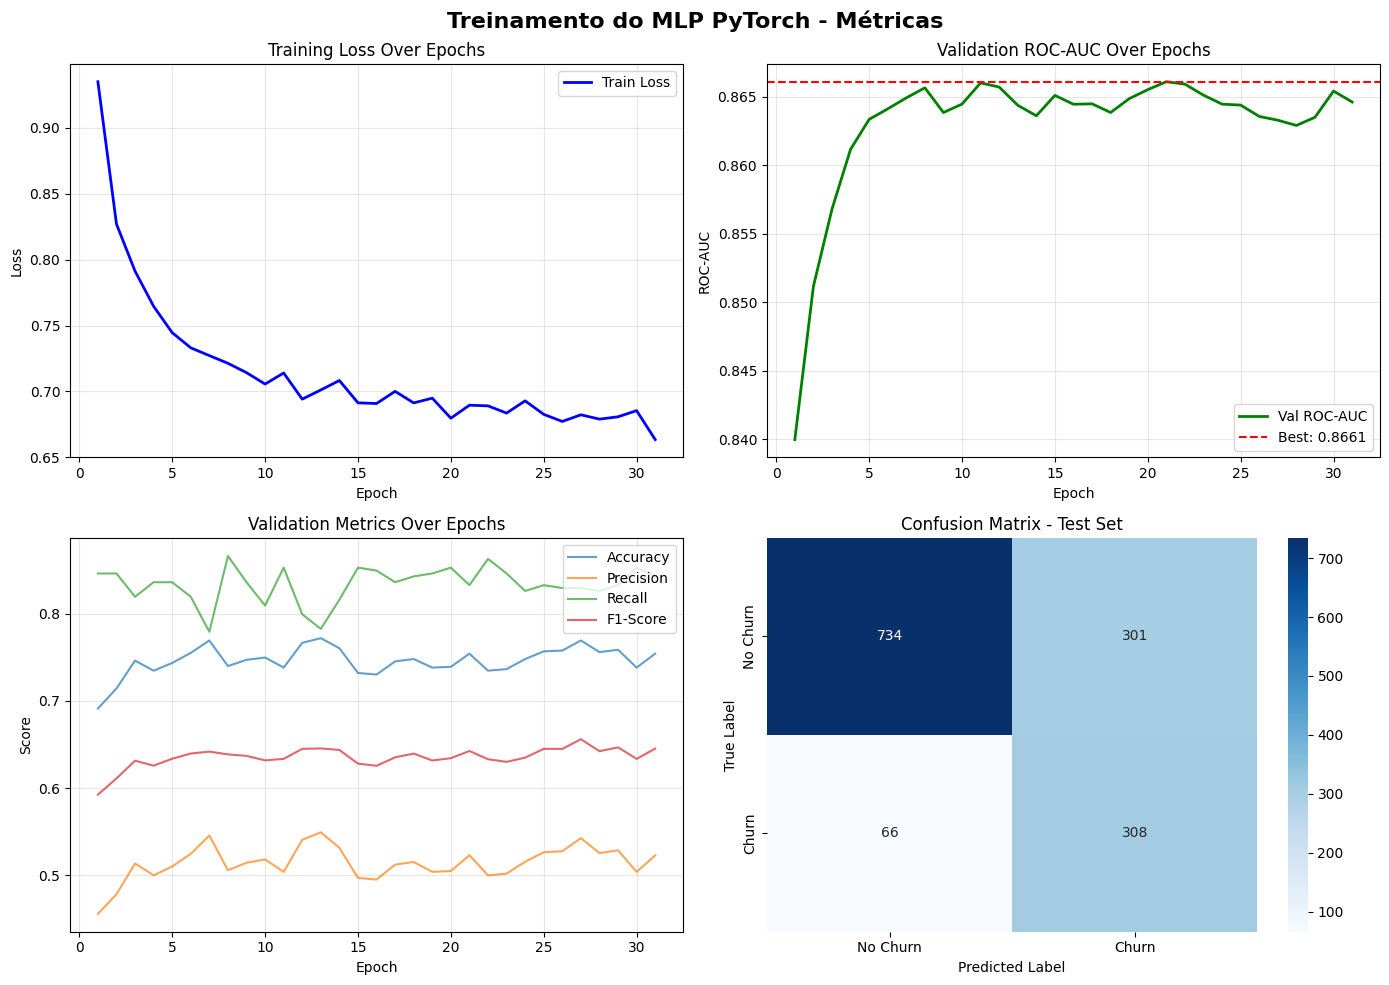


COMPARAÇÃO: MLP PyTorch vs Baseline (Random Forest Tunado)

             Model  ROC-AUC  Accuracy  Precision   Recall  F1-Score
       MLP PyTorch 0.852117  0.739532   0.505747 0.823529  0.626653
RandomForest Tuned 0.845560  0.752307   0.521815 0.799465  0.631468

----------------------------------------------------------------------
ANÁLISE COMPARATIVA:
✓ MLP supera RF em ROC-AUC: 0.8521 vs 0.8456 (+0.0066)
✗ MLP fica abaixo do RF em Accuracy: 0.7395 vs 0.7523 (-0.0128)
✗ MLP fica abaixo do RF em Precision: 0.5057 vs 0.5218 (-0.0161)
✓ MLP supera RF em Recall: 0.8235 vs 0.7995 (+0.0241)
✗ MLP fica abaixo do RF em F1-Score: 0.6267 vs 0.6315 (-0.0048)

----------------------------------------------------------------------
CONCLUSÃO FINAL:
⚠ O MLP não superou o RF de forma consistente no conjunto geral.
⚠ O RF permanece como baseline clássico mais forte.
----------------------------------------------------------------------

✅ Visualizações e comparação concluídas


In [21]:
# Fase 7 - Visualizações e Comparação com Baseline (Random Forest Tuned)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Treinamento do MLP PyTorch - Métricas', fontsize=16, fontweight='bold')

# Plot 1: Training Loss
ax = axes[0, 0]
ax.plot(history['epochs'], history['train_loss'], 'b-', linewidth=2, label='Train Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Validation ROC-AUC (métrica principal)
ax = axes[0, 1]
ax.plot(history['epochs'], history['val_roc_auc'], 'g-', linewidth=2, label='Val ROC-AUC')
ax.axhline(y=best_val_roc_auc, color='r', linestyle='--', label=f'Best: {best_val_roc_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Validation Metrics Comparison
ax = axes[1, 0]
ax.plot(history['epochs'], history['val_accuracy'], label='Accuracy', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_precision'], label='Precision', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_recall'], label='Recall', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_f1'], label='F1-Score', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Validation Metrics Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 4: Confusion Matrix (Test Set)
ax = axes[1, 1]
test_pred_binary = (test_preds_all >= 0.5).astype(int)
cm = confusion_matrix(test_targets_all, test_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('Confusion Matrix - Test Set')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


with open("../models/rf_baseline_metrics.json", "r", encoding="utf-8") as f:
    baseline_metrics = json.load(f)

print("\n" + "="*70)
print("COMPARAÇÃO: MLP PyTorch vs Baseline (Random Forest Tunado)")
print("="*70)

comparison_df = pd.DataFrame([
    {
        "Model": "MLP PyTorch",
        "ROC-AUC": test_metrics["roc_auc"],
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1-Score": test_metrics["f1"],
    },
    {
        "Model": baseline_metrics["Model"],
        "ROC-AUC": baseline_metrics["ROC-AUC"],
        "Accuracy": baseline_metrics["Accuracy"],
        "Precision": baseline_metrics["Precision"],
        "Recall": baseline_metrics["Recall"],
        "F1-Score": baseline_metrics["F1-Score"],
    }
])

print(f"\n{comparison_df.to_string(index=False)}")

# Análise comparativa
print(f"\n{'-'*70}")
print("ANÁLISE COMPARATIVA:")

mlp_metrics = {
    "ROC-AUC": test_metrics["roc_auc"],
    "Accuracy": test_metrics["accuracy"],
    "Precision": test_metrics["precision"],
    "Recall": test_metrics["recall"],
    "F1-Score": test_metrics["f1"],
}

rf_metrics = {
    "ROC-AUC": baseline_metrics["ROC-AUC"],
    "Accuracy": baseline_metrics["Accuracy"],
    "Precision": baseline_metrics["Precision"],
    "Recall": baseline_metrics["Recall"],
    "F1-Score": baseline_metrics["F1-Score"],
}

for metric_name in mlp_metrics:
    mlp_value = mlp_metrics[metric_name]
    rf_value = rf_metrics[metric_name]
    diff = mlp_value - rf_value

    if diff > 0:
        print(f"✓ MLP supera RF em {metric_name}: {mlp_value:.4f} vs {rf_value:.4f} (+{diff:.4f})")
    elif diff < 0:
        print(f"✗ MLP fica abaixo do RF em {metric_name}: {mlp_value:.4f} vs {rf_value:.4f} ({diff:.4f})")
    else:
        print(f"• Empate em {metric_name}: {mlp_value:.4f}")

print(f"\n{'-'*70}")
print("CONCLUSÃO FINAL:")

if (
    mlp_metrics["ROC-AUC"] >= rf_metrics["ROC-AUC"] and
    mlp_metrics["F1-Score"] >= rf_metrics["F1-Score"]
):
    print("✅ O MLP apresenta melhor desempenho geral no conjunto das métricas.")
    print("✅ O RF mantém recall ligeiramente superior ou competitivo, mas o MLP entrega melhor equilíbrio global.")
    print("✅ O MLP PyTorch é o candidato final mais forte até o momento.")
else:
    print("⚠ O MLP não superou o RF de forma consistente no conjunto geral.")
    print("⚠ O RF permanece como baseline clássico mais forte.")
    
print(f"{'-'*70}")
print("\n✅ Visualizações e comparação concluídas")

In [22]:
os.makedirs("../models", exist_ok=True)

# 1. Salvar pesos do modelo MLP
torch.save(model.state_dict(), "../models/best_mlp_model.pth")

# 2. Salvar scaler usado no treino
joblib.dump(scaler, "../models/mlp_scaler.joblib")

# 3. Salvar ordem das features
joblib.dump(list(X.columns), "../models/mlp_features.joblib")

# 4. Salvar métricas finais do MLP
mlp_metrics_export = {
    "Model": "MLP PyTorch",
    "ROC-AUC": float(test_metrics["roc_auc"]),
    "Accuracy": float(test_metrics["accuracy"]),
    "Precision": float(test_metrics["precision"]),
    "Recall": float(test_metrics["recall"]),
    "F1-Score": float(test_metrics["f1"]),
    "Best Val ROC-AUC": float(best_val_roc_auc),
    "Epochs Trained": int(len(history["epochs"]))
}

with open("../models/mlp_metrics.json", "w", encoding="utf-8") as f:
    json.dump(mlp_metrics_export, f, indent=4, ensure_ascii=False)

print("✅ MLP salvo em ../models/best_mlp_model.pth")
print("✅ Scaler salvo em ../models/mlp_scaler.joblib")
print("✅ Features salvas em ../models/mlp_features.joblib")
print("✅ Métricas do MLP salvas em ../models/mlp_metrics.json")

✅ MLP salvo em ../models/best_mlp_model.pth
✅ Scaler salvo em ../models/mlp_scaler.joblib
✅ Features salvas em ../models/mlp_features.joblib
✅ Métricas do MLP salvas em ../models/mlp_metrics.json


In [12]:
# Fase 8 - Finalizar MLflow Run e Resumo

# Finalizar run
mlflow.end_run()

print(f"\n" + f"="*70)
print(f"RESUMO FINAL - TREINAMENTO COMPLETO")
print(f"="*70)

print(f"\n✓ MLflow Run Finalizado")
print(f"  Experiment: tech_challenge_churn_local")
print(f"  Best Val ROC-AUC: {best_val_roc_auc:.4f}")
print(f"  Test ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"  Epochs Trained: {len(history['epochs'])}")

print(f"\n✓ Modelo salvo como artifact do MLflow")
print(f"  Estrutura: 35 → [128, 64, 32, 16] → 1")
print(f"  Parâmetros treináveis: {trainable_params:,}")
print(f"  Ativação: ReLU com BatchNormalization e Dropout regularizado")

print(f"\n✓ Performance no Test Set:")
print(f"  ROC-AUC:  {test_metrics['roc_auc']:.4f} (Baseline: 0.84)")
print(f"  Recall:   {test_metrics['recall']:.4f} (Target: ≥70%)")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  F1-Score:  {test_metrics['f1']:.4f}")

print(f"\n✓ Early Stopping Aplicado")
print(f"  Paciência: {early_stopping_patience} épocas")
print(f"  Épocas completadas: {len(history['epochs'])}")
print(f"  Métrica monitorada: ROC-AUC (validation set)")

print(f"\n" + f"="*70)
print(f"PRÓXIMOS PASSOS:")
print(f"  1. Revisar visualizações e comparação com baseline")
print(f"  2. Consultar MLflow UI para detalhes completos do experimento")
print(f"  3. Se necessário, ajustar hiperparâmetros e treinar novamente")
print(f"  4. Completar notebook 02_baselines com SelectKBest se desejado")
print(f"="*70 + f"\n")


RESUMO FINAL - TREINAMENTO COMPLETO

✓ MLflow Run Finalizado
  Experiment: tech_challenge_churn_local
  Best Val ROC-AUC: 0.8676
  Test ROC-AUC: 0.8489
  Epochs Trained: 37

✓ Modelo salvo como artifact do MLflow
  Estrutura: 35 → [128, 64, 32, 16] → 1
  Parâmetros treináveis: 16,225
  Ativação: ReLU com BatchNormalization e Dropout regularizado

✓ Performance no Test Set:
  ROC-AUC:  0.8489 (Baseline: 0.84)
  Recall:   0.7674 (Target: ≥70%)
  Precision: 0.5345
  F1-Score:  0.6301

✓ Early Stopping Aplicado
  Paciência: 15 épocas
  Épocas completadas: 37
  Métrica monitorada: ROC-AUC (validation set)

PRÓXIMOS PASSOS:
  1. Revisar visualizações e comparação com baseline
  2. Consultar MLflow UI para detalhes completos do experimento
  3. Se necessário, ajustar hiperparâmetros e treinar novamente
  4. Completar notebook 02_baselines com SelectKBest se desejado

